In [52]:
import pyodbc
from sqlalchemy import create_engine , text 
import pandas as pd
import numpy as np

In [53]:
server=r"YASHDEEP\SQLEXPRESS"
database="food_agent"

engine = create_engine(
    f"mssql+pyodbc://@{server}/{database}"
    "?driver=ODBC+Driver+18+for+SQL+Server"
    "&Trusted_Connection=yes"
    "&Encrypt=no"
)


In [54]:
fact_orders= "SELECT * FROM fact_orders"
df_fact_orders = pd.read_sql(fact_orders, engine) 

fact_order_items= "SELECT * FROM fact_order_items" 
df_fact_order_items = pd.read_sql(fact_order_items, engine) 

fact_delivery_performance= "SELECT * FROM fact_delivery_performance" 
df_fact_delivery_performance = pd.read_sql(fact_delivery_performance, engine)

fact_ratings= "SELECT * FROM fact_ratings" 
df_fact_ratings = pd.read_sql(fact_ratings, engine)

In [55]:
dim_restaurant= "SELECT * FROM dbo.dim_restaurant"
df_dim_restaurant = pd.read_sql(dim_restaurant, engine)

dim_menu_item= "SELECT * FROM dbo.dim_menu_item"
df_dim_menu_item = pd.read_sql(dim_menu_item, engine)


dim_customer= "SELECT * FROM dbo.dim_customer"
df_dim_customer = pd.read_sql(dim_customer, engine)



In [56]:

dim_delivery_partner= "SELECT * FROM delivery_partner"
df_dim_delivery_partner = pd.read_sql(dim_delivery_partner, engine)

In [57]:
orders_features = (
    df_fact_orders
    .groupby('customer_id')
    .agg(
        total_orders=('order_id', 'count'),
        total_spend=('total_amount', 'sum'),
        avg_order_value=('total_amount', 'mean'),
        total_discount=('discount_amount', 'sum'),
        total_delivery_fee=('delivery_fee', 'sum'),
        last_order_date=('order_timestamp', 'max')
    )
    .reset_index()
)

In [58]:
cancel_rate = (
    df_fact_orders
    .assign(
        cancelled=lambda x: (
            x['is_cancelled']
            .astype(str)
            .str.upper()
            .eq('Y')
            .astype(int)
        )
    )
    .groupby('customer_id')['cancelled']
    .mean()
    .reset_index(name='cancellation_rate')
)

cancelled_orders = (
    df_fact_orders
    .assign(
        cancelled=lambda x:
        x['is_cancelled']
        .astype(str)
        .str.upper()
        .eq('Y')
        .astype(int)
    )
    .groupby('customer_id')['cancelled']
    .sum()
    .reset_index(name='cancelled_orders')
)

In [59]:
cod_rate = (
    df_fact_orders
    .assign(
        cod=lambda x: (
            x['is_cod']
            .astype(str)
            .str.upper()
            .eq('Y')
            .astype(int)
        )
    )
    .groupby('customer_id')['cod']
    .mean()
    .reset_index(name='cod_rate')
)

In [60]:
ratings_features = (
    df_fact_ratings
    .groupby('customer_id')
    .agg(
        avg_rating=('rating', 'mean'),
        avg_sentiment=('sentiment_score', 'mean'),
        total_reviews=('order_id', 'count')
    )
    .reset_index()
)

In [61]:
delivery_df = (
    df_fact_delivery_performance
    .merge(
        df_fact_orders[['order_id', 'customer_id']],
        on='order_id',
        how='left'
    )
)

In [62]:
delivery_df['delay_minutes'] = (
    delivery_df['actual_delivery_time_mins']
    -
    delivery_df['expected_delivery_time_mins']
)

In [63]:
delivery_df['late_delivery_flag'] = (
    delivery_df['delay_minutes'] > 0
).astype(int)

In [64]:
delivery_features = (
    delivery_df
    .groupby('customer_id')
    .agg(
        avg_actual_delivery_time=(
            'actual_delivery_time_mins',
            'mean'
        ),
        avg_expected_delivery_time=(
            'expected_delivery_time_mins',
            'mean'
        ),
        avg_delay=('delay_minutes', 'mean'),
        late_delivery_rate=(
            'late_delivery_flag',
            'mean'
        )
    )
    .reset_index()
)

In [65]:
customer_df = df_dim_customer.copy()

In [66]:
customer_df = (
    customer_df
    .merge(
        orders_features,
        on='customer_id',
        how='left'
    )
    .merge(
        cancel_rate,
        on='customer_id',
        how='left'
    )
    .merge(
        cancelled_orders,
        on='customer_id',
        how='left'
    )
    .merge(
        cod_rate,
        on='customer_id',
        how='left'
    )
    .merge(
        ratings_features,
        on='customer_id',
        how='left'
    )
    .merge(
        delivery_features,
        on='customer_id',
        how='left'
    )
)

In [67]:
customer_df['signup_date'] = pd.to_datetime(
    customer_df['signup_date']
)

customer_df['last_order_date'] = pd.to_datetime(
    customer_df['last_order_date']
)

C:\Users\tapas\AppData\Local\Temp\ipykernel_16928\2016057572.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  customer_df['signup_date'] = pd.to_datetime(


In [68]:

customer_df['customer_age_days'] = (
    pd.Timestamp.today()
    -
    customer_df['signup_date']
).dt.days

In [69]:
analysis_date = customer_df['last_order_date'].max()

customer_df['recency_days'] = (
    analysis_date - customer_df['last_order_date']
).dt.days

In [70]:
customer_df['discount_dependency'] = (
    customer_df['total_discount']
    /
    (customer_df['total_spend'] + 1)
)

In [71]:
customer_df.shape

(107776, 23)

In [72]:
customer_df = customer_df[
    customer_df['total_orders'] > 0
]

In [73]:
customer_df[['cancelled_orders']].head()

,cancelled_orders
0,0.0
1,0.0
2,1.0
3,0.0
4,0.0


In [74]:
customer_df=customer_df[customer_df['cancelled_orders']==0]

In [75]:

numerical_features = [
    'total_orders',
    'total_spend',
    'avg_order_value',
    'total_discount',
    'total_delivery_fee',
    'customer_age_days',
    'recency_days',
    'discount_dependency',
    'cod_rate',
    'avg_rating',
    'avg_delay',
    'late_delivery_rate'
]

customer_df[numerical_features].corrwith(customer_df['avg_rating'])

total_orders          -0.000399
total_spend            0.003526
avg_order_value        0.006092
total_discount        -0.001170
total_delivery_fee     0.000336
customer_age_days      0.561033
recency_days           0.645447
discount_dependency   -0.005130
cod_rate              -0.038781
avg_rating             1.000000
avg_delay             -0.438965
late_delivery_rate    -0.222480
dtype: float64

In [76]:
# Create copy
customer_knn = customer_df.copy()

# Features for KNN

knn_features = [
    'city',
    'customer_age_days',
    'recency_days',
    'avg_delay',
    'late_delivery_rate',
    'avg_rating'
]


knn_df = customer_knn[knn_features].copy()

# One-Hot Encode city
knn_df = pd.get_dummies(
    knn_df,
    columns=['city'],
    drop_first=True,
    dtype=int
)

print(knn_df.shape)
knn_df.head()

(94357, 12)


,customer_age_days,recency_days,avg_delay,late_delivery_rate,avg_rating,city_Bengaluru,city_Chennai,city_Delhi,city_Hyderabad,city_Kolkata,city_Mumbai,city_Pune
0,450,142.0,12.000000,1.0,5.0,0,0,0,0,0,0,1
1,492,225.0,-2.000000,0.0,NaN,0,0,0,0,1,0,0
3,502,129.0,5.666667,1.0,4.1,0,0,0,1,0,0,0
4,512,233.0,1.000000,1.0,NaN,0,0,0,0,1,0,0
5,346,61.0,-1.000000,0.0,3.0,1,0,0,0,0,0,0


In [77]:
print(knn_df[['avg_rating']].median())
print(knn_df[['avg_rating']].mean())


avg_rating    4.4
dtype: float64
avg_rating    4.052682
dtype: float64


In [78]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer

# Scale
scaler = StandardScaler()
scaled_data = scaler.fit_transform(knn_df)

# KNN Imputation
imputer = KNNImputer(
    n_neighbors=3,
    weights='distance'
)

imputed_data = imputer.fit_transform(scaled_data)

# Back to DataFrame
imputed_df = pd.DataFrame(
    imputed_data,
    columns=knn_df.columns,
    index=knn_df.index
)

In [79]:
# 7. Reverse scaling
imputed_original = pd.DataFrame(
    scaler.inverse_transform(imputed_df),
    columns=knn_df.columns,
    index=knn_df.index
)

# 8. Fill only missing ratings
customer_df_imputed = customer_df.copy()

mask = customer_df_imputed['avg_rating'].isna()

customer_df_imputed.loc[mask, 'avg_rating'] = (
    imputed_original.loc[mask, 'avg_rating']
)
customer_df_imputed.head()


,customer_id,signup_date,city,acquisition_channel,total_orders,total_spend,avg_order_value,total_discount,total_delivery_fee,last_order_date,...,avg_rating,avg_sentiment,total_reviews,avg_actual_delivery_time,avg_expected_delivery_time,avg_delay,late_delivery_rate,customer_age_days,recency_days,discount_dependency
0,CUST000007,2025-03-21,Pune,Organic,1.0,239.39,239.39,0.00,34.50,2025-05-11 12:39:00,...,5.000000,1.00,1.0,47.0,35.000000,12.000000,1.0,450,142.0,0.000000
1,CUST000008,2025-02-07,Kolkata,Referral,1.0,246.05,246.05,0.00,22.47,2025-02-17 21:30:00,...,4.652032,NaN,NaN,28.0,30.000000,-2.000000,0.0,492,225.0,0.000000
3,CUST000010,2025-01-28,Hyderabad,Paid,3.0,652.08,217.36,28.16,95.57,2025-05-24 12:43:00,...,4.100000,0.55,2.0,46.0,40.333333,5.666667,1.0,502,129.0,0.043119
4,CUST000011,2025-01-18,Kolkata,Organic,1.0,146.56,146.56,20.63,25.16,2025-02-09 22:41:00,...,4.400001,NaN,NaN,45.0,44.000000,1.000000,1.0,512,233.0,0.139808
5,CUST000014,2025-07-03,Bengaluru,Paid,1.0,207.05,207.05,51.22,23.17,2025-07-31 14:14:00,...,3.000000,0.00,1.0,47.0,48.000000,-1.000000,0.0,346,61.0,0.246191


In [80]:
mask = customer_df['avg_rating'].isna()
customer_df_imputed.loc[mask, 'avg_rating'].describe()

count    39316.000000
mean         4.065016
std          0.837984
min          1.094712
25%          3.950056
50%          4.402702
75%          4.616007
max          5.000000
Name: avg_rating, dtype: float64

In [81]:
customer_df['avg_rating'].describe()

count    55041.000000
mean         4.052682
std          0.899407
min          1.000000
25%          3.750000
50%          4.400000
75%          4.700000
max          5.000000
Name: avg_rating, dtype: float64

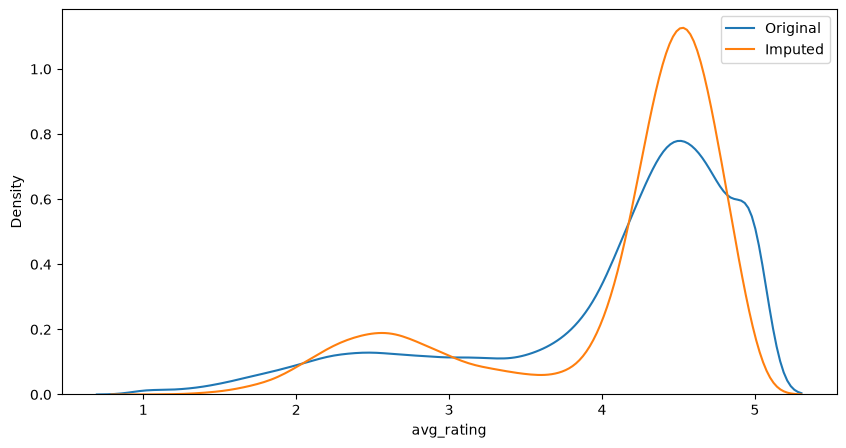

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.kdeplot(
    customer_df.loc[~mask,'avg_rating'],
    label='Original'
)

sns.kdeplot(
    customer_df_imputed.loc[mask,'avg_rating'],
    label='Imputed'
)

plt.legend()
plt.show()

In [83]:
customer_df['month'] = pd.to_datetime(
    customer_df['signup_date']
).dt.to_period('M')

customer_df_imputed['month'] = pd.to_datetime(
    customer_df_imputed['signup_date']
).dt.to_period('M')

monthly_comparison = pd.DataFrame({
    'Original_Avg_Rating': customer_df.groupby('month')['avg_rating'].mean(),
    'Imputed_Avg_Rating': customer_df_imputed.groupby('month')['avg_rating'].mean()
}).reset_index()

print(monthly_comparison)

      month  Original_Avg_Rating  Imputed_Avg_Rating
0   2024-11             4.382553            4.415465
1   2024-12             4.353897            4.389318
2   2025-01             4.333190            4.376991
3   2025-02             4.331791            4.385529
4   2025-03             4.252893            4.302746
5   2025-04             4.047011            4.096623
6   2025-05             3.457856            3.494963
7   2025-06             2.551613            2.566668
8   2025-07             2.473333            2.464891
9   2025-08             2.330000            2.336033
10  2025-09             2.343002            2.336211


# k means model 

In [84]:
customer_df_imputed.describe()

,signup_date,total_orders,total_spend,avg_order_value,total_discount,total_delivery_fee,last_order_date,cancellation_rate,cancelled_orders,cod_rate,avg_rating,avg_sentiment,total_reviews,avg_actual_delivery_time,avg_expected_delivery_time,avg_delay,late_delivery_rate,customer_age_days,recency_days,discount_dependency
count,94357,94357.000000,94357.000000,94357.000000,94357.000000,94357.000000,94357,94357.0,94357.0,94357.000000,94357.000000,55041.000000,55041.000000,94357.000000,94357.000000,94357.000000,94357.000000,94357.000000,94357.000000,94357.000000
mean,2025-03-01 11:32:11.188995,1.382992,486.400466,351.807328,28.247652,44.946191,2025-04-30 05:17:05.413907,0.0,0.0,0.313607,4.057821,0.526341,1.182155,44.193459,38.631181,5.562278,0.636122,469.519315,153.529139,0.063413
min,2024-11-02 00:00:00,1.000000,115.060000,115.060000,0.000000,20.000000,2025-01-01 12:00:00,0.0,0.0,0.000000,1.000000,-1.000000,1.000000,25.000000,30.000000,-20.000000,0.000000,257.000000,0.000000,0.000000
25%,2025-01-07 00:00:00,1.000000,295.950000,276.615000,0.000000,29.020000,2025-03-02 19:57:00,0.0,0.0,0.000000,3.800000,0.375000,1.000000,37.000000,35.000000,-2.000000,0.000000,429.000000,106.000000,0.000000
50%,2025-02-17 00:00:00,1.000000,401.540000,336.190000,0.000000,37.990000,2025-04-23 20:03:00,0.0,0.0,0.000000,4.400000,0.700000,1.000000,42.000000,38.666667,4.000000,1.000000,482.000000,160.000000,0.000000
75%,2025-04-11 00:00:00,2.000000,614.660000,408.680000,49.480000,57.170000,2025-06-16 22:06:00,0.0,0.0,0.666667,4.646497,0.850000,1.000000,49.000000,42.000000,11.333333,1.000000,523.000000,212.000000,0.113284
max,2025-09-30 00:00:00,7.000000,2715.180000,944.910000,394.980000,244.610000,2025-09-30 22:59:00,0.0,0.0,1.000000,5.000000,1.000000,5.000000,90.000000,50.000000,55.000000,1.000000,589.000000,272.000000,0.322202
std,NaN,0.647370,266.437911,108.371267,38.143552,22.665221,NaN,0.0,0.0,0.424397,0.874355,0.449703,0.436392,11.525970,4.617855,11.140310,0.439656,69.065577,72.419254,0.082612


In [85]:
cluster_features = [
    'total_orders',
    'total_spend',
    'avg_order_value',
    'avg_rating',
    'recency_days',
    'discount_dependency'
]

In [86]:
customer_df_imputed[cluster_features].isnull().sum()

total_orders           0
total_spend            0
avg_order_value        0
avg_rating             0
recency_days           0
discount_dependency    0
dtype: int64

In [87]:
log_features = [
    'total_orders',
    'total_spend',
    'discount_dependency'
]

import numpy as np

customer_df_imputed['log_total_orders'] = np.log1p(customer_df_imputed['total_orders'])

customer_df_imputed['log_total_spend'] = np.log1p(customer_df_imputed['total_spend'])

customer_df_imputed['log_discount_dependency'] = np.log1p(customer_df_imputed['discount_dependency'])

# customer_df_imputed['log_avg_order_value'] = np.log1p(customer_df_imputed['avg_order_value'] )

# customer_df_imputed['log_recency'] = np.log1p(customer_df_imputed['recency_days'] )

# customer_df_imputed['log_avg_rating'] = np.log1p(customer_df_imputed['avg_rating'])

In [88]:
cluster_features = [
    'log_total_orders',
    'log_total_spend',
    # 'avg_order_value',
    'avg_rating',
    'recency_days',
    # 'discount_dependency'
]

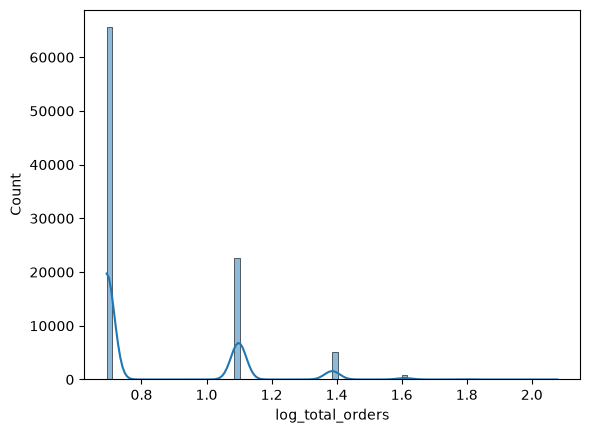

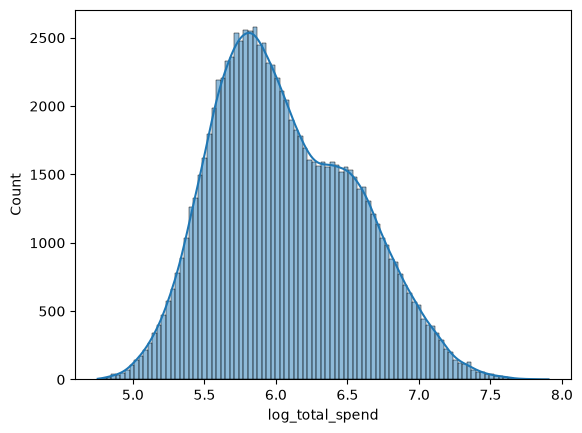

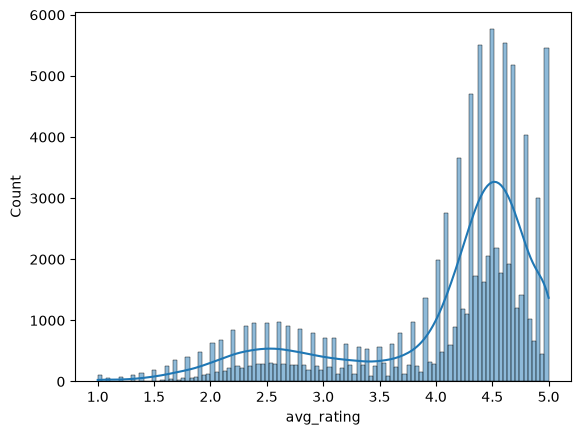

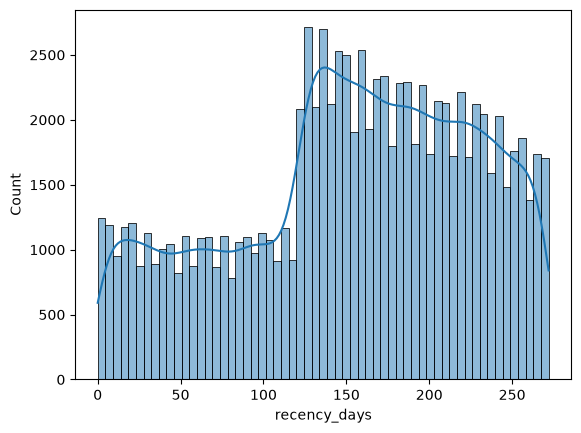

In [89]:
for col in cluster_features:
    sns.histplot(customer_df_imputed[col], kde=True)
    plt.show()

In [90]:
X = customer_df_imputed[cluster_features].copy()


In [91]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

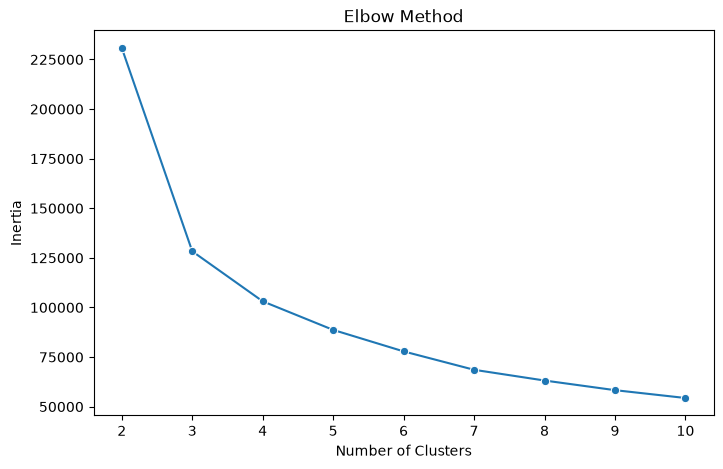

In [92]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

inertia = []

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

sns.lineplot(
    x=range(2,11),
    y=inertia,
    marker='o'
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()

In [93]:
from sklearn.metrics import silhouette_score
import pandas as pd

X_sample = pd.DataFrame(
    X_scaled
).sample(
    10000,
    random_state=42
)

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(
        X_sample
    )

    score = silhouette_score(
        X_sample,
        labels
    )

    print(
        f"K={k} | Silhouette={score:.4f}"
    )

K=2 | Silhouette=0.4188
K=3 | Silhouette=0.5020
K=4 | Silhouette=0.4861
K=5 | Silhouette=0.3329
K=6 | Silhouette=0.3373
K=7 | Silhouette=0.3455
K=8 | Silhouette=0.3341
K=9 | Silhouette=0.3269
K=10 | Silhouette=0.2941


In [94]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

customer_df_imputed["cluster"] = kmeans.fit_predict(
    X_scaled
)

customer_df_imputed["cluster"].value_counts()

cluster
1    50941
3    18362
2    14603
0    10451
Name: count, dtype: int64

In [95]:
cluster_profile = customer_df_imputed.groupby("cluster")[[
    'total_orders',
    'total_spend',
    # 'avg_order_value',
    'avg_rating',
    'recency_days',
    # 'discount_dependency'
]].mean().round(2)

cluster_profile

,total_orders,total_spend,avg_rating,recency_days
cluster,,,,
0,2.34,823.60,3.27,52.05
1,1.00,351.37,4.50,197.53
2,1.00,351.32,2.51,61.02
3,2.20,776.52,4.51,162.79


In [96]:
segment_map = {
    0: "High-Value Active Customers",
    1: "Dormant Satisfied Customers",
    2: "Dissatisfied Active Customers",
    3: "VIP Loyal Customers"
}

customer_df_imputed["segment"] = customer_df_imputed["cluster"].map(segment_map)

In [97]:
customer_df_imputed.head()

,customer_id,signup_date,city,acquisition_channel,total_orders,total_spend,avg_order_value,total_discount,total_delivery_fee,last_order_date,...,late_delivery_rate,customer_age_days,recency_days,discount_dependency,month,log_total_orders,log_total_spend,log_discount_dependency,cluster,segment
0,CUST000007,2025-03-21,Pune,Organic,1.0,239.39,239.39,0.00,34.50,2025-05-11 12:39:00,...,1.0,450,142.0,0.000000,2025-03,0.693147,5.482263,0.000000,1,Dormant Satisfied Customers
1,CUST000008,2025-02-07,Kolkata,Referral,1.0,246.05,246.05,0.00,22.47,2025-02-17 21:30:00,...,0.0,492,225.0,0.000000,2025-02,0.693147,5.509591,0.000000,1,Dormant Satisfied Customers
3,CUST000010,2025-01-28,Hyderabad,Paid,3.0,652.08,217.36,28.16,95.57,2025-05-24 12:43:00,...,1.0,502,129.0,0.043119,2025-01,1.386294,6.481700,0.042215,3,VIP Loyal Customers
4,CUST000011,2025-01-18,Kolkata,Organic,1.0,146.56,146.56,20.63,25.16,2025-02-09 22:41:00,...,1.0,512,233.0,0.139808,2025-01,0.693147,4.994235,0.130859,1,Dormant Satisfied Customers
5,CUST000014,2025-07-03,Bengaluru,Paid,1.0,207.05,207.05,51.22,23.17,2025-07-31 14:14:00,...,0.0,346,61.0,0.246191,2025-07,0.693147,5.337778,0.220092,2,Dissatisfied Active Customers


In [98]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

customer_df_imputed['PCA1'] = X_pca[:, 0]
customer_df_imputed['PCA2'] = X_pca[:, 1]

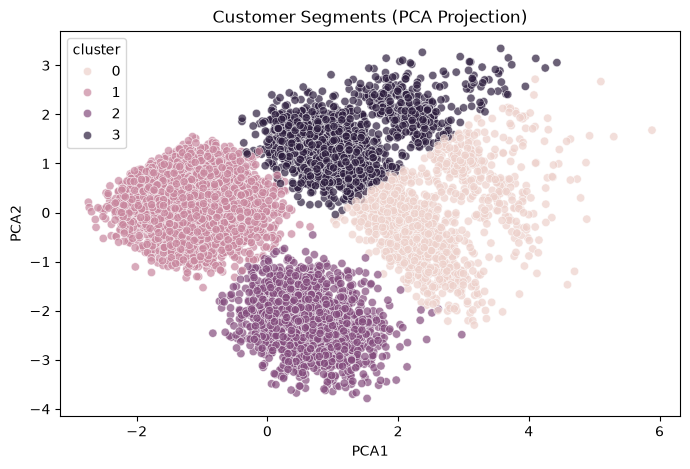

In [99]:
plt.figure(figsize=(8,5))

plot_df = customer_df_imputed.sample(
    10000,
    random_state=42
)

sns.scatterplot(
    data=plot_df,
    x='PCA1',
    y='PCA2',
    hue='cluster',
    alpha=0.7
)

plt.title('Customer Segments (PCA Projection)')
plt.show()

In [100]:
from sklearn.decomposition import PCA

pca_3d = PCA(n_components=3)

X_pca_3d = pca_3d.fit_transform(X_scaled)

customer_df_imputed['PC1'] = X_pca_3d[:,0]
customer_df_imputed['PC2'] = X_pca_3d[:,1]
customer_df_imputed['PC3'] = X_pca_3d[:,2]

print("Explained Variance Ratio:")
print(pca_3d.explained_variance_ratio_)

print("\nTotal Variance Explained:")
print(pca_3d.explained_variance_ratio_.sum())

Explained Variance Ratio:
[0.50953278 0.37379163 0.06873699]

Total Variance Explained:
0.9520613954952531


In [102]:
import plotly.express as px

plot_df = customer_df_imputed.sample(
    10000,
    random_state=42
)

fig = px.scatter_3d(
    plot_df,
    x='PC1',
    y='PC2',
    z='PC3',
    color='cluster',
    opacity=1,
    title='QuickBite Customer Segments (3D PCA)'
)

fig.show(renderer='browser')

---------------------------------------------------------------------

# Model B: Recovery Score Engine

In [103]:
from sklearn.preprocessing import MinMaxScaler

recovery_df = customer_df_imputed.copy()

scaler = MinMaxScaler()

In [104]:
recovery_df.shape

(94357, 34)

In [105]:
recovery_df['rating_risk'] = (
    5 - recovery_df['avg_rating']
) / 4

recovery_df['delay_risk'] = MinMaxScaler().fit_transform(
    recovery_df[['avg_delay']]
)

recovery_df['recency_risk'] = MinMaxScaler().fit_transform(
    recovery_df[['recency_days']]
)




In [106]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

recovery_df['orders_score'] = scaler.fit_transform(
    recovery_df[['total_orders']]
)

recovery_df['spend_score'] = scaler.fit_transform(
    recovery_df[['total_spend']]
)

In [107]:
recovery_df['value_score'] = (
      recovery_df['orders_score'] * 0.6
    + recovery_df['spend_score'] * 0.4
) * 100

recovery_df['value_score'] = (
    recovery_df['value_score']
    .round(2)
)

In [108]:
recovery_df['dissatisfaction_score'] = (
      recovery_df['rating_risk']
    + recovery_df['delay_risk']
    + recovery_df['recency_risk']
) / 3 * 100

recovery_df['dissatisfaction_score'] = (
    recovery_df['dissatisfaction_score']
    .round(2)
)

In [109]:
recovery_df['recovery_priority_score'] = (
    recovery_df['value_score']
    *
    recovery_df['dissatisfaction_score']
) / 100


In [110]:
recovery_df['recovery_priority_score'] = (
      recovery_df['dissatisfaction_score'] * 0.7
    + recovery_df['value_score'] * 0.3
)

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

recovery_df['recovery_priority_score'] =( scaler.fit_transform(
    recovery_df[['recovery_priority_score']]
) * 100).round(2)



In [111]:
recovery_df[[
    'value_score',
    'dissatisfaction_score',
    'recovery_priority_score'
]].describe()

,value_score,dissatisfaction_score,recovery_priority_score
count,94357.000000,94357.000000,94357.000000
mean,9.542583,38.027331,42.054162
std,10.192530,8.067309,11.403061
min,0.000000,6.410000,0.000000
25%,2.780000,32.460000,34.150000
50%,4.430000,37.690000,41.820000
75%,17.100000,43.330000,49.510000
max,94.010000,77.830000,100.000000


In [112]:
vq1 = recovery_df['value_score'].quantile(0.25)
vq2 = recovery_df['value_score'].quantile(0.50)
vq3 = recovery_df['value_score'].quantile(0.75)


q1 = recovery_df['recovery_priority_score'].quantile(0.25)
q2 = recovery_df['recovery_priority_score'].quantile(0.50)
q3 = recovery_df['recovery_priority_score'].quantile(0.75)

print(q1, q2, q3)

34.15 41.82 49.51


In [113]:
def priority_band(score):

    if score >= q3:
        return "Critical"

    elif score >= q2:
        return "High"

    elif score >= q1:
        return "Medium"

    else:
        return "Low"


recovery_df['priority_band'] = (
    recovery_df['recovery_priority_score']
    .apply(priority_band)
)

recovery_df.sort_values(
    'recovery_priority_score',
    ascending=False
)

,customer_id,signup_date,city,acquisition_channel,total_orders,total_spend,avg_order_value,total_discount,total_delivery_fee,last_order_date,...,PC3,rating_risk,delay_risk,recency_risk,orders_score,spend_score,value_score,dissatisfaction_score,recovery_priority_score,priority_band
48021,CUST088976,2025-01-15,Bengaluru,Organic,3.0,1108.51,369.503333,27.40,77.46,2025-06-27 12:46:00,...,2.023333,1.000000,0.662222,0.349265,0.333333,0.382079,35.28,67.05,100.00,Critical
53784,CUST099675,2025-05-21,Chennai,Organic,1.0,415.86,415.860000,0.00,36.64,2025-06-02 20:40:00,...,1.845634,0.958764,0.933333,0.441176,0.000000,0.115687,4.63,77.78,96.52,Critical
94427,CUST175214,2025-01-27,Chennai,Paid,4.0,1954.73,488.682500,0.00,109.13,2025-06-02 12:57:00,...,2.040714,0.825000,0.373333,0.441176,0.500000,0.707533,58.30,54.65,96.33,Critical
47017,CUST087142,2025-03-06,Bengaluru,Paid,4.0,1326.16,331.540000,64.98,126.74,2025-06-08 14:30:00,...,2.107412,0.975000,0.366667,0.419118,0.500000,0.465786,48.63,58.69,96.18,Critical
28996,CUST053647,2025-05-13,Chennai,Organic,1.0,371.54,371.540000,56.57,25.45,2025-06-06 22:08:00,...,1.766572,0.975000,0.933333,0.426471,0.000000,0.098642,3.95,77.83,96.17,Critical
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67323,CUST124835,2025-01-15,Kolkata,Paid,2.0,834.46,417.230000,0.00,66.99,2025-09-23 12:35:00,...,-1.654306,0.000000,0.166667,0.025735,0.166667,0.276680,21.07,6.41,3.46,Low
55222,CUST102206,2025-02-03,Delhi,Referral,2.0,624.63,312.315000,34.38,60.48,2025-09-12 12:28:00,...,-1.713260,0.025000,0.126667,0.066176,0.166667,0.195979,17.84,7.26,2.69,Low
105357,CUST195458,2025-02-16,Delhi,Organic,2.0,438.81,219.405000,0.00,47.75,2025-09-25 12:23:00,...,-2.182453,0.000000,0.213333,0.018382,0.166667,0.124513,14.98,7.72,1.58,Low
52967,CUST098146,2025-07-27,Mumbai,Paid,1.0,207.89,207.890000,20.03,25.23,2025-09-19 21:59:00,...,-1.859794,0.200000,0.133333,0.040441,0.000000,0.035702,1.43,12.46,0.04,Low


In [114]:
recovery_df.nlargest(
    10,
    'recovery_priority_score'
)[[
    'segment',
    'total_orders',
    'total_spend',
    'avg_rating',
    'avg_delay',
    'recency_days',
    'recovery_priority_score',
    'priority_band'
]]

,segment,total_orders,total_spend,avg_rating,avg_delay,recency_days,recovery_priority_score,priority_band
48021,High-Value Active Customers,3.0,1108.51,1.000000,29.666667,95.0,100.00,Critical
53784,Dissatisfied Active Customers,1.0,415.86,1.164946,50.000000,120.0,96.52,Critical
94427,High-Value Active Customers,4.0,1954.73,1.700000,8.000000,120.0,96.33,Critical
47017,High-Value Active Customers,4.0,1326.16,1.100000,7.500000,114.0,96.18,Critical
28996,Dissatisfied Active Customers,1.0,371.54,1.100000,50.000000,116.0,96.17,Critical
48480,High-Value Active Customers,5.0,1552.63,1.700000,25.800000,33.0,94.72,Critical
99258,Dissatisfied Active Customers,1.0,271.38,1.100000,50.000000,112.0,94.50,Critical
70838,Dissatisfied Active Customers,1.0,291.23,1.500000,55.000000,115.0,93.61,Critical
27928,Dissatisfied Active Customers,1.0,460.82,1.400000,48.000000,115.0,91.94,Critical
81345,High-Value Active Customers,4.0,1564.10,1.300000,22.250000,37.0,91.88,Critical


In [115]:
delay_threshold = recovery_df['avg_delay'].quantile(0.75)

recency_threshold = recovery_df['recency_days'].quantile(0.75)

In [116]:
recovery_df['flag_low_rating'] = (
    recovery_df['avg_rating'] < 3
).astype(int)

recovery_df['flag_delivery_delay'] = (
    recovery_df['avg_delay'] > delay_threshold
).astype(int)

recovery_df['flag_inactive'] = (
    recovery_df['recency_days'] > recency_threshold
).astype(int)

recovery_df['flag_high_value'] = (
    recovery_df['value_score'] > vq3
).astype(int)

# recommendations

In [117]:
def recommendation_engine(row):

    segment = row['segment']
    priority = row['priority_band']

    # VIP Customers
    if segment == "VIP Loyal Customers":

        if priority == "Critical":
            return "VIP Retention Program + 100 Coupon"

        elif priority == "High":
            return "₹50 Coupon"

        else:
            return "No Action Needed"

    # High Value Customers
    elif segment == "High-Value Active Customers":

        if priority == "Critical":
            return "Customer Support Follow-up + ₹100 Coupon"

        elif priority == "High":
            return "₹50 Coupon"

        else:
            return "Monitor"

    # Dissatisfied Customers
    elif segment == "Dissatisfied Active Customers":

        if priority == "Critical":
            return "Support Follow-up + Free Delivery"

        elif priority == "High":
            return "₹30 Coupon"

        else:
            return "Monitor"

    # Dormant Customers
    elif segment == "Dormant Satisfied Customers":

        if priority == "Critical":
            return "Re-engagement Campaign + 50 Coupon"

        elif priority == "High":
            return "Re-engagement Campaign"

        else:
            return "Monitor"

    return "Monitor"

In [118]:
recovery_df['recommendation'] = (
    recovery_df.apply(
        recommendation_engine,
        axis=1
    )
)

In [119]:
def expected_goal(rec):

    if "VIP" in rec:
        return "Prevent VIP Churn"

    elif "Support" in rec:
        return "Improve Customer Satisfaction"

    elif "Campaign" in rec:
        return "Reactivate Customer"

    elif "Coupon" in rec:
        return "Increase Repeat Orders"

    return "No Immediate Goal"

recovery_df['business_goal'] = (
    recovery_df['recommendation']
    .apply(expected_goal)
)

In [120]:
customer_intelligence = recovery_df[[

    'customer_id',

    'segment',

    'flag_low_rating',
    'flag_delivery_delay',
    'flag_inactive',
    'flag_high_value',

    'recovery_priority_score',

    'priority_band',


    'recommendation',

    'business_goal'

]]
customer_intelligence.head()

,customer_id,segment,flag_low_rating,flag_delivery_delay,flag_inactive,flag_high_value,recovery_priority_score,priority_band,recommendation,business_goal
0,CUST000007,Dormant Satisfied Customers,0,1,0,0,28.05,Low,Monitor,No Immediate Goal
1,CUST000008,Dormant Satisfied Customers,0,0,1,0,38.03,Medium,Monitor,No Immediate Goal
3,CUST000010,VIP Loyal Customers,0,0,0,1,48.87,High,₹50 Coupon,Increase Repeat Orders
4,CUST000011,Dormant Satisfied Customers,0,0,1,0,43.47,High,Re-engagement Campaign,Reactivate Customer
5,CUST000014,Dissatisfied Active Customers,0,0,0,0,29.15,Low,Monitor,No Immediate Goal


In [121]:
# Store DataFrame
customer_intelligence.to_sql(
    name='customer_reccommendations',
    con=engine,
    if_exists='replace',      # replace / append
    index=False
)

print(f"Loaded {len(customer_intelligence)} rows successfully.")

Loaded 94357 rows successfully.
